[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

In [2]:
# Definimos una cantidad aleatoria de centroides entre 1 y 20
n_centroides_random = np.random.randint(1, 20)

# Generamos los datos con dispersión amplia para asegurar la distancia
X, y = make_blobs(n_samples=2000,
                  centers=n_centroides_random,
                  cluster_std=0.7,
                  center_box=(-20.0, 20.0),
                  random_state=42)

print(f"Cantidad de centroides generada aleatoriamente: {n_centroides_random}")

Cantidad de centroides generada aleatoriamente: 17


In [3]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

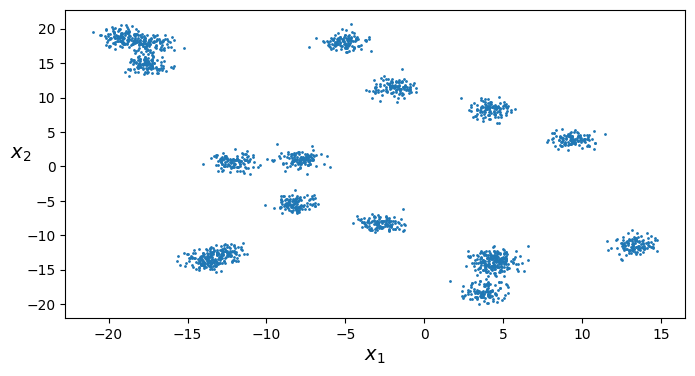

In [4]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [5]:
#ENTRENAMIENTO Y VERIFICACIÓN VISUAL
k = n_centroides_random

kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([15,  6,  9, ...,  4,  4, 15], dtype=int32)

In [6]:
kmeans.cluster_centers_

array([[ -7.86937537,   1.01533199],
       [  4.41219109, -13.79799414],
       [-17.32678776,  17.84983685],
       [-13.89388389, -13.81091948],
       [  9.36176277,   3.9040275 ],
       [ -5.08462831,  18.10358455],
       [ 13.34314667, -11.42271723],
       [ -8.18206596,  -5.41224345],
       [ -2.76244781,  -8.28547759],
       [ -1.9178705 ,  11.46439794],
       [  4.20147165,   8.28219149],
       [  3.7851224 , -18.20614766],
       [-12.68595797,   0.78975611],
       [-19.15245459,  18.78930503],
       [-12.6797361 , -12.52962056],
       [-17.58714398,  14.76150929],
       [-11.51169688,   0.53533151]])

In [7]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([10, 10,  0,  0], dtype=int32)

In [8]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

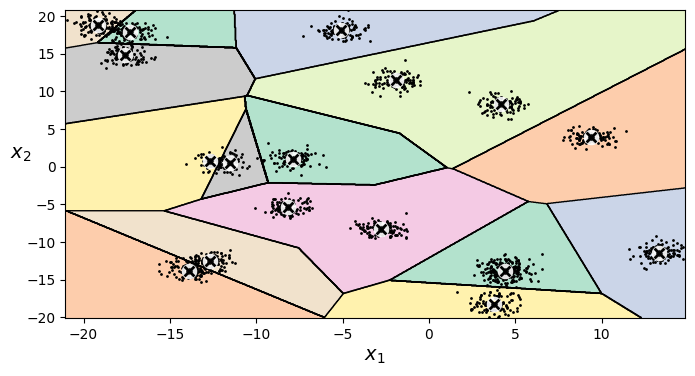

In [9]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [10]:
kmeans.transform(X_new)

array([[ 7.93074018, 16.40256227, 23.48265109, 21.04816344,  9.55342466,
        16.88724016, 18.9264075 , 11.04026976, 10.64998437,  9.65676217,
         7.55766458, 20.5576155 , 12.74355601, 25.46953631, 19.28433512,
        21.72932932, 11.60449994],
       [10.91388529, 15.86098681, 25.775873  , 23.13846338,  6.64058327,
        18.01906352, 16.94550149, 13.4156607 , 11.7896927 , 10.66584636,
         6.39605066, 20.22139512, 15.73257664, 27.79589911, 21.37671625,
        24.22161466, 14.58542424],
       [ 5.25830045, 18.36064225, 20.63430401, 20.03206729, 12.39477488,
        15.24676823, 21.7970919 ,  9.88026556, 11.28797747,  8.53328991,
         8.93099887, 22.26518773,  9.93493633, 22.58769449, 18.29935533,
        18.73813946,  8.86135286],
       [ 5.09068322, 17.90433438, 20.99700785, 19.6143519 , 12.44124077,
        15.74222113, 21.46952487,  9.45819243, 10.78809334,  9.02947588,
         9.23552556, 21.78950291,  9.83578751, 22.93999231, 17.87699038,
        19.05595392

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [11]:
from sklearn import set_config

# Esto desactiva la representación visual que causa el conflicto
set_config(display='text')

In [12]:
# Aseguramos que k sea el valor aleatorio generado al principio
k_random = n_centroides_random

kmeans_iter1 = KMeans(n_clusters=k_random, init="k-means++", n_init=1,
                      algorithm="lloyd", max_iter=1, random_state=4)

kmeans_iter2 = KMeans(n_clusters=k_random, init="k-means++", n_init=1,
                      algorithm="lloyd", max_iter=2, random_state=4)

kmeans_iter3 = KMeans(n_clusters=k_random, init="k-means++", n_init=1,
                      algorithm="lloyd", max_iter=3, random_state=4)

# Entrenamos los modelos
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

print(f"Modelos entrenados exitosamente para k={k_random}")

Modelos entrenados exitosamente para k=17


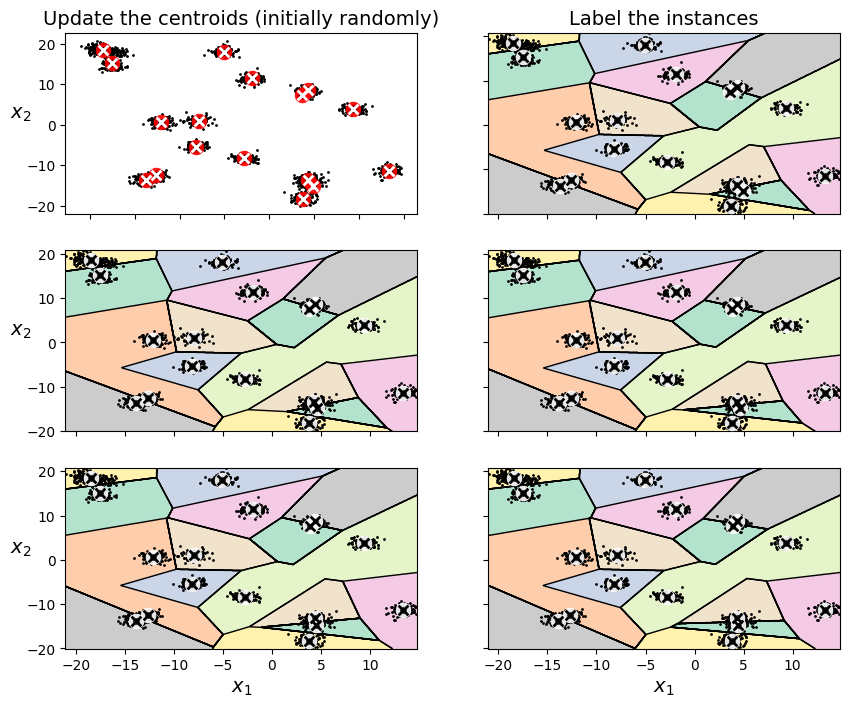

In [13]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [14]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

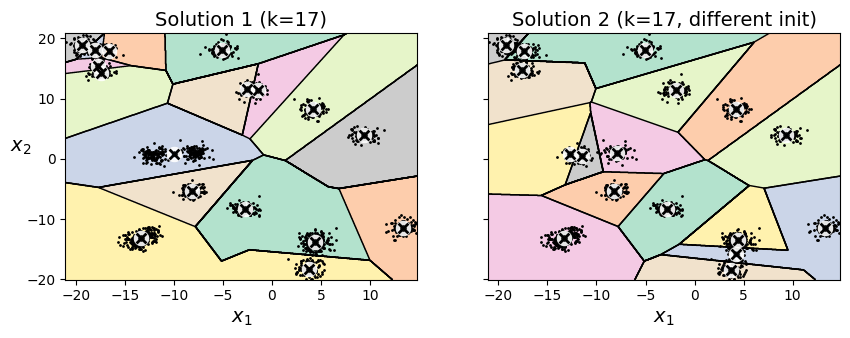

In [15]:
k_random = n_centroides_random

kmeans_rnd_init1 = KMeans(n_clusters=k_random, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k_random, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          f"Solution 1 (k={k_random})",
                          f"Solution 2 (k={k_random}, different init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [16]:
# Usamos la variable k_random (n_centroides_random)
k_random = n_centroides_random

# Ajustamos n_clusters para ser consistente con el dataset aleatorio
kmeans_rnd_10_inits = KMeans(n_clusters=k_random, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=17, n_init=10,
       random_state=11)

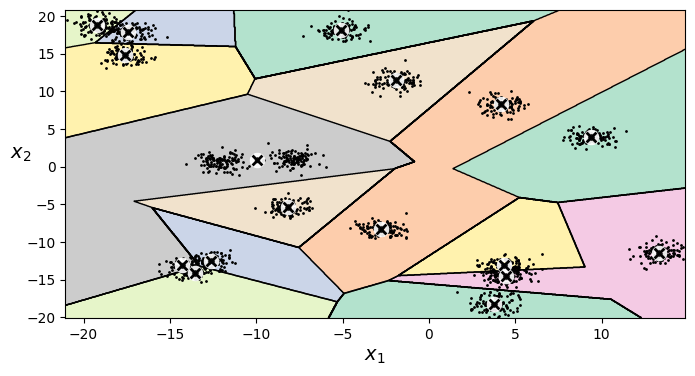

In [17]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Otras mejoras al algoritmo de *K-Means* incluyen: *K-Means* acelerados (usado por *Scikit-Learn* por defecto y que evita algunos cálculos de distancias) y *mini-batch K-Means* (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html?highlight=minibatchkmeans#sklearn.cluster.MiniBatchKMeans).

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

from sklearn.cluster import MiniBatchKMeans

# Usamos la cantidad aleatoria de centroides generada al principio
k = n_centroides_random
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    # Se aplica k aleatorio y se asegura compatibilidad con n_init
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=1)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

### Encontrando el número óptimo de grupos

Como hemos visto anteriormente, el número de grupos o *clusters* es un hyperparámetro del modelo que debemos definir, y como podrás imaginar si nuestros datos no están etiquetados no será imposible saber qué valor usar. Para ello la solución se basa en usar diferentes valores y utilizar alguna métrica significativa. Una de estas métricas se conoce como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) de todas las muestras del dataset como $(b-a)/\mathrm{max}(a,b)$ donde $a$ es la distancia mínima al resto de muestras del mismo grupo y $b$ es la distancia media de los grupos más cercanos. Su valor se encuentra entre $1$ y $-1$. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo y lejos de los demás mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

In [ ]:
# Usamos n_centroides_random para definir el rango de búsqueda
# Buscaremos desde 2 hasta el número real de centros + un margen (máximo 20)
limit_k = min(20, n_centroides_random + 5)

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, limit_k + 1)]

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

# El eje X debe empezar en 2 porque no existe Silhouette para k=1
ks = range(2, limit_k + 1)

plt.figure(figsize=(8, 4))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Métrica de Silhouette para Verificación de Clusters", fontsize=14)

# Ajuste dinámico de los ejes
plt.axis([1.5, limit_k + 0.5, 0, 1])
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

In [ ]:
# Solo incluimos los k que realmente fueron entrenados en kmeans_per_k
valid_ks = [k for k in range(1, 20) if k <= len(kmeans_per_k)]

# Ajustamos el tamaño de la figura para que quepan todos los gráficos (puedes aumentarlo si se ve pequeño)
plt.figure(figsize=(15, 30))

for plot_idx, k in enumerate(valid_ks):
    # CAMBIO: Creamos una cuadrícula de 7 filas y 3 columnas (espacio para 21 gráficos)
    plt.subplot(7, 3, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    plt.ylabel("Cluster")
    plt.xlabel("Silhouette Coefficient")

    # Línea roja: indica el score promedio para ese k
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=14)
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ajuste automático para que no se traslapen los títulos
plt.tight_layout()
plt.show()

### K-Means para aprendizaje semi-supervisado.

PARTE 2

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

In [ ]:
import tarfile
import zipfile
import os

# Ruta del archivo
archivo_comprimido = '/content/gdrive/MyDrive/IA26/LAB7/archive (5).zip'
# Carpeta de destino
ruta_destino = './IP102_data'

def descomprimir_dataset(ruta_archivo):
    # VALIDACIÓN: Si la carpeta ya existe, no perdemos tiempo descomprimiendo
    if os.path.exists(ruta_destino):
        print(f"La carpeta {ruta_destino} ya existe. Saltando descompresión.")
        return

    print("Descomprimiendo dataset... por favor espera.")
    if ruta_archivo.endswith('.tar') or ruta_archivo.endswith('.tar.gz'):
        with tarfile.open(ruta_archivo, 'r') as tar:
            tar.extractall(path=ruta_destino)
            print("Extracción de TAR completada.")
    elif ruta_archivo.endswith('.zip'):
        with zipfile.ZipFile(ruta_archivo, 'r') as zip_ref:
            zip_ref.extractall(ruta_destino)
            print("Extracción de ZIP completada.")
    else:
        print("Formato no reconocido.")

# Ejecución
if os.path.exists(archivo_comprimido):
    descomprimir_dataset(archivo_comprimido)
else:
    print(f"Error: No se encontró el archivo en {archivo_comprimido}")

In [ ]:
import cv2
import numpy as np
import os
from sklearn.utils import shuffle

def cargar_desde_carpetas_color(ruta_base, n_max=10000):
    X, y = [], []
    if not os.path.exists(ruta_base):
        print(f"Error: {ruta_base} no existe.")
        return np.array([]), np.array([])

    subcarpetas = sorted([d for d in os.listdir(ruta_base) if os.path.isdir(os.path.join(ruta_base, d))])

    for folder in subcarpetas:
        ruta_folder = os.path.join(ruta_base, folder)
        etiqueta = int(folder)

        for archivo in os.listdir(ruta_folder):
            if archivo.endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(os.path.join(ruta_folder, archivo))
                if img is None: continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))

                X.append(img.flatten())
                y.append(etiqueta)

                if len(X) >= n_max: break
        if len(X) >= n_max: break
    return np.array(X), np.array(y)

# Cargamos por separado
path_train = './IP102_data/classification/train'
path_test = './IP102_data/classification/test'

X_train, y_train_real = cargar_desde_carpetas_color(path_train, n_max=10005)
X_test, y_test_real = cargar_desde_carpetas_color(path_test, n_max=2000)

# MEZCLAMOS SOLO TRAIN (y Test por su cuenta, sin juntarlos)
X_train, y_train_real = shuffle(X_train, y_train_real, random_state=42)
X_test, y_test_real = shuffle(X_test, y_test_real, random_state=42)

print(f"Cargadas {len(X_train)} imágenes de entrenamiento a COLOR.")

In [ ]:
from sklearn.utils import shuffle
import numpy as np

# MEZCLAMOS TODO EL SET DE ENTRENAMIENTO
X_train, y_train_real = shuffle(X_train, y_train_real, random_state=42)

# BORRAMOS LAS ETIQUETAS (Simulación de Dataset no etiquetado)
# Creamos un array lleno de -1, que significa "sin etiqueta" para Scikit-Learn
y_train_unlabeled = np.full(shape=y_train_real.shape, fill_value=-1)

# VERIFICACIÓN
print(f"Total de imágenes en Train: {X_train.shape[0]}")
print(f"Número de etiquetas conocidas: {np.sum(y_train_unlabeled != -1)}")
print(f"Número de etiquetas ocultas (-1): {np.sum(y_train_unlabeled == -1)}")
print("Las imágenes han sido mezcladas y las etiquetas eliminadas exitosamente.")

No Supervisado

El K-Means. Agrupa los bichos por colores y formas sin saber sus nombres.

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Definimos los rangos de clusters que queremos probar
k_range = [10, 30, 50, 70]
inercias = []
siluetas = []

print("Calculando métricas óptimas (Codo y Silueta)...")

for k in k_range:
    # Usamos MiniBatch por velocidad
    kmeans_temp = MiniBatchKMeans(n_clusters=k, n_init=5, random_state=42)
    kmeans_temp.fit(X_train)

    # Guardamos Inercia (para el Codo)
    inercias.append(kmeans_temp.inertia_)

    # Guardamos Silueta (usamos una muestra de 2000 para que no tarde horas)
    # El Silhouette Score va de -1 a 1 (mientras más alto, mejor)
    indices_muestra = np.random.choice(len(X_train), 2000, replace=False)
    score = silhouette_score(X_train[indices_muestra], kmeans_temp.labels_[indices_muestra])
    siluetas.append(score)

    print(f"Prueba con k={k} terminada. Silueta: {score:.4f}")

# 2. GRAFICAMOS AMBOS RESULTADOS
plt.figure(figsize=(14, 5))

# Gráfico del Codo
plt.subplot(1, 2, 1)
plt.plot(k_range, inercias, 'bo-', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo (Buscamos el quiebre)')
plt.grid(True)

# Gráfico de Silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, siluetas, 'ro-', linewidth=2)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Análisis de Silueta (Buscamos el punto más alto)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Ejecutamos el K-Means con k=30 (Totalmente a ciegas)
k_final = 50
kmeans_final = MiniBatchKMeans(n_clusters=k_final, n_init=10, random_state=42)
kmeans_final.fit(X_train)

# Buscamos las fotos que mejor representan a cada grupo
X_dist = kmeans_final.transform(X_train)
representative_idx = np.argmin(X_dist, axis=0)
X_rep_color = X_train[representative_idx]

# Visualización
plt.figure(figsize=(20, 15))

for i, img_flat in enumerate(X_rep_color):
    plt.subplot(5, 10, i + 1)

    plt.imshow(img_flat.reshape(128, 128, 3))

    # ponemos el ID del grupo que inventó el K-Means
    plt.title(f"Patrón Detectado #{i}", fontsize=12)
    plt.axis("off")

plt.suptitle("Punto 2: Identificación de 30 Ptrones de Plagas", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Semisupervisado
Etiquetamos los 50 "jefes" y se la ponemos automáticamente a los otros

In [ ]:
# Asignados según lo que se observa
nombres_50_plagas = {
    0: "Cicadellidae (Saltahojas)", 1: "Red spider (Araña roja)", 2: "White backed plant hopper",
    3: "Paddy stem maggot", 4: "Rice leaf roller", 5: "Rice leafhopper",
    6: "Small brown plant hopper", 7: "Rice gall midge", 8: "Rice Stemfly",
    9: "White grub (Gusano blanco)", 10: "Mole cricket (Grillo topo)", 11: "Rice water weevil",
    12: "Grain spreader thrips", 13: "Rice leaf caterpillar", 14: "Brown plant hopper",
    15: "Yellow rice borer", 16: "Rice shell pest", 17: "Wireworm",
    18: "White margined moth", 19: "Black cutworm", 20: "Large cutworm",
    21: "Yellow cutworm", 22: "Corn borer", 23: "Army worm",
    24: "Aphids (Pulgones)", 25: "Potosiabre vitarsis", 26: "Peach borer",
    27: "English grain aphid", 28: "Green bug", 29: "Bird cherry-oat aphid",
    30: "Wheat blossom midge", 31: "Penthaleus major", 32: "Longlegged spider mite",
    33: "Wheat phloeothrips", 34: "Wheat sawfly", 35: "Cerodonta denticornis",
    36: "Beet fly", 37: "Flea beetle", 38: "Cabbage army worm",
    39: "Beet army worm", 40: "Beet spot flies", 41: "Meadow moth",
    42: "Beet weevil", 43: "Alfalfa weevil", 44: "Flax budworm",
    45: "Alfalfa plant bug", 46: "Tarnished plant bug", 47: "Locustoidea (Langosta)",
    48: "Lytta polita", 49: "Blister beetle"
}

# Visualización Final de los 50 Patrones con Nombres
plt.figure(figsize=(25, 20))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(X_rep_color[i].reshape(128, 128, 3))
    # Título con el nombre único
    plt.title(f"Patrón {i}:\n{nombres_50_plagas[i]}", fontsize=8, color='navy')
    plt.axis("off")

plt.suptitle("Punto 2: Clasificación de 50 Patrones Únicos (Aprendizaje Semisupervisado)", fontsize=25)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Creamos un array para las etiquetas de las 10,000 imágenes
y_train_final_names = np.empty(len(X_train), dtype=object)

for i in range(k_final):
    # Todos los insectos que el K-Means puso en el grupo 'i'
    # ahora se llamarán como el nombre que se eligio
    y_train_final_names[kmeans_final.labels_ == i] = nombres_50_plagas[i]

print(f"¡Hecho! Ahora las {len(X_train)} imágenes tienen su nombre de plaga asignado.")

In [ ]:
from sklearn.linear_model import LogisticRegression

# Entrenamos el modelo con las 10,000 imágenes y sus nuevos nombres
# Usamos un max_iter alto porque las imágenes de 128x128 son pesadas
print("Entrenando el modelo final... esto puede tardar un minuto.")
modelo_plagas = LogisticRegression(max_iter=1000, multi_class="ovr")
modelo_plagas.fit(X_train, y_train_final_names)

print("Modelo entrenado exitosamente.")

In [ ]:
from sklearn.metrics import classification_report

# El modelo intenta adivinar las plagas del set de prueba
y_pred = modelo_plagas.predict(X_test)

# Para comparar, necesitamos convertir las etiquetas reales de números a nombres
print("--- REPORTE DE CLASIFICACIÓN ---")
# Esto te mostrará la precisión (Accuracy) de tu experimento
print(classification_report(y_test_real, y_pred, labels=list(range(len(nombres_50_plagas)))))

APRENDIZAJE ACTIVO

In [ ]:
# El modelo hace predicciones sobre TODO el set de entrenamiento
# Queremos ver qué tan seguro está de cada foto
probas = modelo_plagas.predict_proba(X_train)

# Buscamos la "Incertidumbre": las fotos donde la probabilidad más alta es la más baja
# Es decir, fotos donde el modelo dice: "No estoy seguro de qué es esto"
probabilidades_maximas = probas.max(axis=1)
indices_mas_inciertos = np.argsort(probabilidades_maximas)[:10]

# Visualizamos esas 10 imágenes "difíciles" para que las corrijamos
plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices_mas_inciertos):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx].reshape(128, 128, 3))

    # Obtenemos el nombre real usando la etiqueta oculta y_train_real
    nombre_real = nombres_50_plagas.get(y_train_real[idx], "Plaga Desconocida")

    # CORRECCIÓN MANUAL: Actualizamos la etiqueta con la verdad
    y_train_final_names[idx] = nombre_real

    plt.title(f"Difícil #{i}\nReal: {nombre_real}", fontsize=9)
    plt.axis("off")

plt.suptitle("Aprendizaje Activo: Corrigiendo las 10 muestras con mayor incertidumbre", fontsize=16)
plt.show()

# Re-entrenamos el modelo con estas 10 correcciones críticas
modelo_plagas.fit(X_train, y_train_final_names)
print("Modelo mejorado con Aprendizaje Activo.")